# Lecture 9: Model Tracking, Reproducibility and Deployment

In this lecture, we cover the essential steps that come after training a machine learning model: **tracking experiments**, ensuring **reproducibility**, and **deploying** models to production.

```{note}
These practices help you transition from exploratory notebooks to **production-ready systems** with clear lineage, stable behavior, and operational visibility.
```


:::{admonition} Learning Objectives
:class: tip
After this lecture, you will be able to:
- Track experiments systematically using MLflow (parameters, metrics, artifacts)
- Ensure model reproducibility through environment pinning and serialisation
- Export models to ONNX for framework-agnostic deployment
- Serve models via REST APIs using FastAPI
- Implement basic model monitoring (latency, drift detection, performance decay)
:::

## Setup: California Housing dataset (used throughout)

We’ll use **California Housing** for every data example in this notebook.

- Task: **regression**
- Target: median house value (in $100k units in the original dataset)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from fun_ds.plotting import set_lecture_style

set_lecture_style()

np.random.seed(42)

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")

# Optional: subsample for speed in docs builds
if len(X) > 12000:
    idx = np.random.choice(len(X), size=12000, replace=False)
    X = X.iloc[idx].reset_index(drop=True)
    y = y.iloc[idx].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1, min_samples_leaf=2
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R²:   {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")


Test R²:   0.8008
Test RMSE: 0.4990
Test MAE:  0.3273


## Model Tracking with MLflow

### Keeping Track of Your Models

```{note}
Keeping track of our models helps in multiple ways:

**Reproducibility**
: Captures experiment details so you can reconstruct results later.

**Performance monitoring**
: Track model performance and drift over time.

**Collaboration**
: Teammates can see what was tried and what worked.

**Experiment management**
: Avoids “model_final_v3_actually_final.pkl” chaos.

**Deployment governance**
: Maintains lineage for auditing and compliance.

**Optimization**
: Enables systematic comparisons across runs.
```


### What is MLflow?

MLflow is an open-source platform for **experiment tracking** and **model packaging**. It provides:

- A central place to log experiments, parameters, and metrics
- Storage for trained models and artifacts
- A UI to visualize and compare runs
- Optional tooling around model registry and deployment

```{tip}
Even if your company uses custom deployment pipelines, MLflow tracking/model packaging is still valuable as a **source of truth** for what was trained and why.
```


### How to log a model to MLflow (California Housing)

The cell below is **runnable**. If MLflow isn’t installed, it will print install instructions.


In [2]:
# MLflow tracking example (optional dependency)
try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    print("MLflow is not installed. Install with: pip install mlflow")
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

    # Start an MLflow run
    with mlflow.start_run(run_name="housing_random_forest_baseline"):
        # Parameters
        params = {
            "n_estimators": 200,
            "min_samples_leaf": 2,
            "random_state": 42,
        }
        for k, v in params.items():
            mlflow.log_param(k, v)

        # Train
        m = RandomForestRegressor(
            n_estimators=params["n_estimators"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=params["random_state"],
            n_jobs=-1,
        )
        m.fit(X_train, y_train)

        # Predict + metrics
        pred = m.predict(X_test)
        r2 = r2_score(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)

        mlflow.log_metric("r2", r2)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)

        # Log model artifact
        mlflow.sklearn.log_model(m, "model")

        print(f"Logged run with R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")


MLflow is not installed. Install with: pip install mlflow


### How to store generic artifacts to MLflow

Beyond the model, we often log artifacts like plots and feature importance.

```{note}
Artifacts help you answer “*what happened?*” when you return to a run later.
```


In [3]:
# Logging plots + JSON/text artifacts (optional dependency)
try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    print("MLflow is not installed. Install with: pip install mlflow")
else:
    import tempfile, os

    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

    with mlflow.start_run(run_name="housing_with_artifacts"):
        m = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1, min_samples_leaf=2)
        m.fit(X_train, y_train)
        pred = m.predict(X_test)

        r2 = r2_score(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)

        mlflow.log_metric("r2", r2)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)

        # 1) Predicted vs Actual plot
        plt.figure(figsize=(5, 5))
        plt.scatter(y_test, pred, alpha=0.25)
        lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
        plt.plot(lims, lims)
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Predicted vs Actual (test)")
        plt.grid(True, alpha=0.2)

        with tempfile.TemporaryDirectory() as tmpdir:
            plot_path = os.path.join(tmpdir, "pred_vs_actual.png")
            plt.savefig(plot_path, dpi=150, bbox_inches="tight")
            mlflow.log_artifact(plot_path, "plots")
        plt.close()

        # 2) Feature importance as JSON (tree models)
        importances = m.feature_importances_
        importance_dict = {name: float(imp) for name, imp in zip(X.columns, importances)}
        mlflow.log_dict(importance_dict, "feature_importance.json")

        # 3) Metrics summary as text
        summary = (
            f"R2: {r2:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\n"
            f"n_train: {len(X_train)}\nn_test: {len(X_test)}\n"
        )
        mlflow.log_text(summary, "metrics_summary.txt")

        mlflow.sklearn.log_model(m, "model")
        print("Logged model + artifacts (plot, JSON, text).") 


MLflow is not installed. Install with: pip install mlflow


### Running MLflow locally

MLflow stores runs in a local `mlruns/` directory by default. To start the UI:

```bash
mlflow ui
# or: mlflow ui --backend-store-uri /path/to/mlruns
# or: mlflow ui --port 5001
```

By default, the UI is at `http://localhost:5000`.

```{tip}
When using Sphinx builds, avoid starting servers inside the doc build. Instead, keep “how to run” commands as *documentation* (Markdown) as above.
```


### Predict from a stored MLflow model

Loading a model requires a **real run id** or a registry entry. The snippet below shows common patterns; you’ll need to substitute actual identifiers from your MLflow UI.

```python
import mlflow.sklearn

run_id = "<YOUR_RUN_ID>"
model = mlflow.sklearn.load_model(f"runs:/{run_id}/model")

# Or: load from the Model Registry (if enabled)
# model = mlflow.sklearn.load_model("models:/housing_regressor/Production")

preds = model.predict(X_test.iloc[:5])
```


### Common MLflow setups

- **Local development:** filesystem tracking (`mlruns/`)
- **Team server:** remote DB + shared artifact store (S3/Blob/GCS/NFS)
- **Production:** auth + encryption + model registry + controlled stage transitions

```{hint}
Treat the tracking server and artifact store as shared infrastructure—similar to a database—rather than something each developer configures ad-hoc.
```


## Reproducibility

### The importance of reproducibility

```{note}
Reproducibility matters for:

**Collaboration**
: Others can verify and build on your results.

**Debugging**
: A stable “ground truth” helps isolate regressions.

**Production**
: Models need to behave consistently across environments.

**Scientific integrity**
: Results should be verifiable and explainable.
```


### Why your code alone does not guarantee reproducibility

```{warning}
Even with identical code, results can differ because of:

- **Package version changes** (behavior or defaults change)
- **Dependency updates** (indirect deps change)
- **OS/hardware differences** (floating-point quirks)
- **Non-determinism** (parallelism, RNG, GPU ops)
- **Data mutation** (raw data changed underneath you)
```


Here is an example of the kind of change you might encounter across versions:

```python
# This code may yield slightly different results across scikit-learn versions
# due to changes in RNG streams or algorithmic details.
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
```


### Ways to persist your model

We can group options into **environment-dependent** vs **environment-independent** formats.


#### Environment-dependent formats: Pickle / cloudpickle

Pickle is easy but binds you to “the same Python + dependency stack”.

```{warning}
Pickle can execute arbitrary code on load. Never unpickle untrusted data.
```


In [4]:
# Pickle example (environment-dependent)
import pickle

with open("housing_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("housing_model.pkl", "rb") as f:
    loaded = pickle.load(f)

pred0 = model.predict(X_test.iloc[:3])
pred1 = loaded.predict(X_test.iloc[:3])
print("Predictions identical (within tolerance):", np.allclose(pred0, pred1))


Predictions identical (within tolerance): True


#### Environment-independent formats: ONNX

ONNX can remove the dependency on a specific Python stack at inference time (depending on what you deploy).

```{note}
Not every model converts cleanly to ONNX, and some conversions require extra configuration.
Always **verify equivalence** after conversion.
```


### Reproduce your training environment

Compare these two environment specifications:

**Loose** (`environment.yml`): you get *some* compatible environment, but not necessarily identical versions.

```yaml
name: datascience
channels: [conda-forge, defaults]
dependencies:
  - python=3.9
  - scikit-learn
  - pandas
  - numpy
  - matplotlib
  - jupyter
```

**Pinned** (`conda-lock.yml`): fully pinned versions, including indirect dependencies.

```yaml
name: datascience
dependencies:
  - python=3.9.13
  - scikit-learn=1.1.2
  - pandas=1.4.3
  # ... plus indirect deps ...
```

```{hint}
Use `conda-lock` (or equivalent tooling) when you need “same results, same environment” across machines and time.
```


### MLflow stores an environment specification for you

When you log a model, MLflow typically stores a `conda.yaml` (or `requirements.txt`) describing dependencies used for that model.

```{tip}
If you later need to reproduce a model exactly, use the stored environment file alongside the run’s artifacts.
```


## What is ONNX?

ONNX is a standard format for representing ML models as a computation graph. It is often used to deploy models in environments where you don’t want to ship the full training framework.

### Key concepts

- **Operators**: operations like `MatMul`, `Add`, `Relu`, ...
- **Tensors**: multi-dimensional arrays
- **Nodes**: operator applications in the graph
- **Graph**: the whole DAG
- **Initializers**: constant tensors (weights/biases)

```{note}
Think of ONNX as a domain-specific language for ML inference graphs.
```


### Building an ONNX graph from scratch (toy example)

We build a simple model: **y = 2x + 1**.

The next cell is runnable if `onnx` is installed.


In [5]:
# Build an ONNX model from scratch (optional dependency)
try:
    import onnx
    from onnx import helper, TensorProto
except ImportError:
    print("onnx is not installed. Install with: pip install onnx")
else:
    # Input/Output
    X_in = helper.make_tensor_value_info("X", TensorProto.FLOAT, [None, 1])
    Y_out = helper.make_tensor_value_info("Y", TensorProto.FLOAT, [None, 1])

    # Initializers
    W = helper.make_tensor("W", TensorProto.FLOAT, [1, 1], [2.0])
    b = helper.make_tensor("b", TensorProto.FLOAT, [1], [1.0])

    # Nodes
    matmul_node = helper.make_node("MatMul", inputs=["X", "W"], outputs=["XW"], name="matmul")
    add_node = helper.make_node("Add", inputs=["XW", "b"], outputs=["Y"], name="add")

    graph = helper.make_graph(
        nodes=[matmul_node, add_node],
        name="LinearRegressionToy",
        inputs=[X_in],
        outputs=[Y_out],
        initializer=[W, b],
    )
    onnx_model = helper.make_model(graph, producer_name="onnx-example")
    onnx.checker.check_model(onnx_model)
    onnx.save(onnx_model, "linear_model.onnx")
    print("Saved: linear_model.onnx")


onnx is not installed. Install with: pip install onnx


Now we can run inference with ONNX Runtime (if installed).

In [6]:
# Inference with ONNX Runtime (optional dependency)
try:
    import onnxruntime as ort
except ImportError:
    print("onnxruntime is not installed. Install with: pip install onnxruntime")
else:
    session = ort.InferenceSession("linear_model.onnx")
    input_name = session.get_inputs()[0].name

    X_ex = np.array([[1.0], [2.0], [3.0], [4.0]], dtype=np.float32)
    Y_pred = session.run(None, {input_name: X_ex})[0]

    print("Input:\n", X_ex)
    print("Predictions (y=2x+1):\n", Y_pred)


onnxruntime is not installed. Install with: pip install onnxruntime


### Converting a scikit-learn model (California Housing) to ONNX

We’ll train a **small** regression model and attempt conversion via `skl2onnx`.

```{warning}
Conversion support varies by estimator and opset. Always verify numerical equivalence.
```


In [7]:
# Convert a sklearn model to ONNX (optional dependencies)
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as ort
except ImportError:
    print("Missing dependencies. Install with: pip install skl2onnx onnxruntime")
else:
    from sklearn.linear_model import LinearRegression

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Baseline predictions
    sk_pred = lr.predict(X_test.iloc[:50])

    # Convert
    initial_type = [("float_input", FloatTensorType([None, X_train.shape[1]]))]
    onnx_model = convert_sklearn(lr, initial_types=initial_type, target_opset=12)

    onnx_path = "housing_linear_regression.onnx"
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

    # Run ONNX
    sess = ort.InferenceSession(onnx_path)
    in_name = sess.get_inputs()[0].name
    X_onnx = X_test.iloc[:50].to_numpy(dtype=np.float32)
    onnx_pred = sess.run(None, {in_name: X_onnx})[0].ravel()

    print("ONNX ~= sklearn (allclose):", np.allclose(sk_pred, onnx_pred, rtol=1e-5, atol=1e-6))


Missing dependencies. Install with: pip install skl2onnx onnxruntime


## Deploying a model

When deploying models to production, accuracy is necessary but not sufficient. You need to consider:

- **Validation & robustness**
- **Latency / throughput**
- **Infrastructure constraints**
- **Monitoring & alerting**
- **Reproducibility & governance**


### Performance and accuracy checks (regression)

Validation report
R²:   0.8008
RMSE: 0.4990
MAE:  0.3273


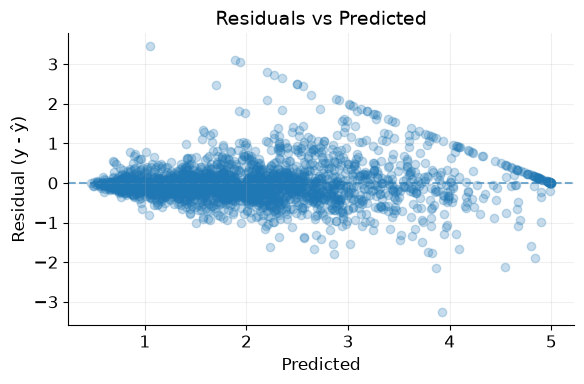

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def validate_before_deployment_regression(model, X_val, y_val):
    pred = model.predict(X_val)
    r2 = r2_score(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)

    print("Validation report")
    print("=" * 50)
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")

    resid = y_val - pred

    plt.figure(figsize=(6, 4))
    plt.scatter(pred, resid, alpha=0.25)
    plt.axhline(0, linestyle="--", alpha=0.6)
    plt.xlabel("Predicted")
    plt.ylabel("Residual (y - ŷ)")
    plt.title("Residuals vs Predicted")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    return {"r2": r2, "rmse": rmse, "mae": mae}

_ = validate_before_deployment_regression(model, X_test, y_test)


### Edge case testing (regression)

```{tip}
Edge-case tests are also useful to detect preprocessing mismatches between training and production.
```


In [9]:
def test_edge_cases_regression(model, X_reference: pd.DataFrame):
    ranges = [(X_reference[c].min(), X_reference[c].max()) for c in X_reference.columns]

    X_min = np.array([[lo for lo, hi in ranges]], dtype=float)
    X_max = np.array([[hi for lo, hi in ranges]], dtype=float)
    X_zero = np.zeros((1, len(ranges)), dtype=float)

    pred_min = model.predict(X_min)[0]
    pred_max = model.predict(X_max)[0]
    pred_zero = model.predict(X_zero)[0]

    print(f"Prediction at min feature values: {pred_min:.3f}")
    print(f"Prediction at max feature values: {pred_max:.3f}")
    print(f"Prediction at all zeros:          {pred_zero:.3f}")

    X_extreme = np.array([[hi * 10 for lo, hi in ranges]], dtype=float)
    pred_extreme = model.predict(X_extreme)[0]
    print(f"Prediction at extreme values:     {pred_extreme:.3f} (out-of-distribution test)")

test_edge_cases_regression(model, X_train)


Prediction at min feature values: 3.053


Prediction at max feature values: 4.334
Prediction at all zeros:          1.750


Prediction at extreme values:     4.376 (out-of-distribution test)


/Users/christian.roerig/Research/fun_ds/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/christian.roerig/Research/fun_ds/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/christian.roerig/Research/fun_ds/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/christian.roerig/Research/fun_ds/.pixi/envs/default/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


### Scalability and infrastructure: latency vs throughput

In [10]:
import time

def benchmark_model_regression(model, X_test: pd.DataFrame, batch_sizes=(1, 10, 100), n_iters=50):
    Xn = X_test
    results = {}

    for bs in batch_sizes:
        lat = []
        iters = min(n_iters, max(1, len(Xn) // bs))
        for i in range(iters):
            start = (i * bs) % len(Xn)
            batch = Xn[start:start + bs]

            t0 = time.time()
            _ = model.predict(batch)
            lat.append(time.time() - t0)

        mean_ms = np.mean(lat) * 1000
        p95_ms = np.percentile(lat, 95) * 1000
        throughput = bs / np.mean(lat)

        results[bs] = {"mean_latency_ms": mean_ms, "p95_latency_ms": p95_ms, "throughput_per_sec": throughput}

        print(f"Batch size {bs:4d} | mean={mean_ms:7.2f}ms | p95={p95_ms:7.2f}ms | throughput={throughput:8.2f}/s")

    return results

_ = benchmark_model_regression(model, X_test, batch_sizes=(1, 10, 200))


Batch size    1 | mean=  15.92ms | p95=  28.56ms | throughput=   62.80/s


Batch size   10 | mean=  13.64ms | p95=  14.08ms | throughput=  732.99/s
Batch size  200 | mean=  14.88ms | p95=  19.96ms | throughput=13436.89/s


### ONNX Runtime performance benefits (optional)

In [11]:
# Compare sklearn vs ONNX inference speed (optional)
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as ort
except ImportError:
    print("Missing dependencies. Install with: pip install skl2onnx onnxruntime")
else:
    import time
    from sklearn.linear_model import LinearRegression

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    initial_type = [("float_input", FloatTensorType([None, X_train.shape[1]]))]
    onnx_model = convert_sklearn(lr, initial_types=initial_type, target_opset=12)
    onnx_path = "housing_lr_bench.onnx"
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

    sess = ort.InferenceSession(onnx_path)
    in_name = sess.get_inputs()[0].name
    Xf = X_test.to_numpy(dtype=np.float32)

    def time_sklearn(n_runs=50):
        ts = []
        for _ in range(n_runs):
            t0 = time.time()
            _ = lr.predict(X_test)
            ts.append(time.time() - t0)
        return np.mean(ts) * 1000

    def time_onnx(n_runs=50):
        ts = []
        for _ in range(n_runs):
            t0 = time.time()
            _ = sess.run(None, {in_name: Xf})
            ts.append(time.time() - t0)
        return np.mean(ts) * 1000

    sk_ms = time_sklearn()
    onnx_ms = time_onnx()
    print(f"Sklearn mean: {sk_ms:.2f}ms")
    print(f"ONNX mean:    {onnx_ms:.2f}ms")
    print(f"Speedup:      {sk_ms / onnx_ms:.2f}x")


Missing dependencies. Install with: pip install skl2onnx onnxruntime


## Monitoring and maintenance

```{note}
Without monitoring, failures show up as business incidents rather than ML alerts.
```


### Logging predictions (simple example)

In [12]:
import logging
from datetime import datetime

class ModelMonitor:
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.predictions = []
        self.timestamps = []

        logging.basicConfig(
            filename=f"{model_name}_predictions.log",
            level=logging.INFO,
            format="%(asctime)s - %(message)s"
        )

    def log_prediction(self, input_row: np.ndarray, prediction: float):
        ts = datetime.now()
        entry = {
            "timestamp": ts.isoformat(),
            "prediction": float(prediction),
        }
        logging.info(entry)
        self.predictions.append(float(prediction))
        self.timestamps.append(ts)

    def get_prediction_summary(self, last_n=200):
        recent = self.predictions[-last_n:]
        if not recent:
            return None
        return {
            "n": len(recent),
            "mean": float(np.mean(recent)),
            "std": float(np.std(recent)),
            "min": float(np.min(recent)),
            "max": float(np.max(recent)),
        }

monitor = ModelMonitor("housing_regressor_demo")
p = model.predict(X_test.iloc[:1])[0]
monitor.log_prediction(X_test.iloc[0].to_numpy(), p)
print("Recent prediction summary:", monitor.get_prediction_summary())


Recent prediction summary: {'n': 1, 'mean': 0.79230233531746, 'std': 0.0, 'min': 0.79230233531746, 'max': 0.79230233531746}


### Detect data drift (KS test)

```{warning}
Treat drift detection as a trigger for investigation, not an automatic “retrain now” command.
```


In [13]:
from scipy.stats import ks_2samp

def detect_data_drift_ks(X_ref: pd.DataFrame, X_new: pd.DataFrame, threshold=0.05):
    print("Data Drift Detection (KS test)")
    print("=" * 60)
    drifted = []
    for col in X_ref.columns:
        stat, p = ks_2samp(X_ref[col].to_numpy(), X_new[col].to_numpy())
        is_drift = p < threshold
        if is_drift:
            drifted.append(col)
        status = "⚠️  DRIFT" if is_drift else "✓ OK"
        print(f"{col:12s}: p-value={p:8.4g} {status}")
    print("=" * 60)
    if drifted:
        print(f"Drift detected in {len(drifted)} features: {drifted}")
    else:
        print("No significant drift detected.")
    return drifted

X_prod = X_test.copy()
X_prod["MedInc"] = X_prod["MedInc"] * 1.2  # simulate a shift
_ = detect_data_drift_ks(X_train, X_prod, threshold=0.01)


Data Drift Detection (KS test)
MedInc      : p-value=5.315e-60 ⚠️  DRIFT
HouseAge    : p-value=  0.1209 ✓ OK
AveRooms    : p-value=  0.5649 ✓ OK
AveBedrms   : p-value=  0.8517 ✓ OK
Population  : p-value=  0.2311 ✓ OK
AveOccup    : p-value=  0.9182 ✓ OK
Latitude    : p-value=  0.3722 ✓ OK
Longitude   : p-value=  0.5574 ✓ OK
Drift detected in 1 features: ['MedInc']


### Monitor model performance (when labels arrive)

In [14]:
from collections import deque
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class PerformanceMonitorRegression:
    def __init__(self, window_size=1000):
        self.y_true = deque(maxlen=window_size)
        self.y_pred = deque(maxlen=window_size)

    def add(self, pred, actual):
        self.y_true.append(float(actual))
        self.y_pred.append(float(pred))

    def metrics(self):
        if len(self.y_true) < 20:
            return None
        yt = np.array(self.y_true)
        yp = np.array(self.y_pred)
        return {
            "n": len(yt),
            "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
            "mae": float(mean_absolute_error(yt, yp)),
            "r2": float(r2_score(yt, yp)),
        }

pm = PerformanceMonitorRegression(window_size=500)

for a, p in zip(y_test.iloc[:300], model.predict(X_test.iloc[:300])):
    pm.add(p, a)

print("Rolling metrics:", pm.metrics())


Rolling metrics: {'n': 300, 'rmse': 0.5306084658693704, 'mae': 0.34096160067652154, 'r2': 0.7755636997071882}


## Test that model behavior is the same in production

```{note}
For regression, we verify equivalence with tolerance (`np.allclose`) instead of exact equality.
```


In [15]:
import os, pickle

def production_equivalence_test_regression(model, X_sample: pd.DataFrame):
    print("Production equivalence test (regression)")
    print("=" * 60)

    base = model.predict(X_sample)

    # Pickle round-trip
    with open("temp_model.pkl", "wb") as f:
        pickle.dump(model, f)
    with open("temp_model.pkl", "rb") as f:
        m2 = pickle.load(f)
    pred_pickle = m2.predict(X_sample)
    print("✓ Pickle allclose:", np.allclose(base, pred_pickle))

    # Optional ONNX check
    try:
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType
        import onnxruntime as ort
        convertible = True
    except ImportError:
        convertible = False
        print("ONNX check skipped (install skl2onnx + onnxruntime).")

    if convertible:
        from sklearn.linear_model import LinearRegression
        lr = LinearRegression().fit(X_train, y_train)
        base_lr = lr.predict(X_sample)

        initial_type = [("float_input", FloatTensorType([None, X_sample.shape[1]]))]
        onnx_model = convert_sklearn(lr, initial_types=initial_type, target_opset=12)
        onnx_path = "temp_model.onnx"
        with open(onnx_path, "wb") as f:
            f.write(onnx_model.SerializeToString())

        sess = ort.InferenceSession(onnx_path)
        in_name = sess.get_inputs()[0].name
        Xf = X_sample.to_numpy(dtype=np.float32)
        onnx_pred = sess.run(None, {in_name: Xf})[0].ravel()

        print("✓ ONNX allclose (LinearRegression):", np.allclose(base_lr, onnx_pred, rtol=1e-5, atol=1e-6))

    # cleanup
    for pth in ["temp_model.pkl", "temp_model.onnx"]:
        try:
            os.remove(pth)
        except Exception:
            pass

    print("=" * 60)

production_equivalence_test_regression(model, X_test.iloc[:50])


Production equivalence test (regression)
✓ Pickle allclose: True
ONNX check skipped (install skl2onnx + onnxruntime).


## Simple model deployment example (end-to-end sketch)

1. Train a simple regression model (California Housing)
2. Convert to ONNX
3. Define request/response schemas (Pydantic)
4. Define a FastAPI app (without starting it inside docs)
5. Show how to call it (curl / requests)

```{warning}
In Sphinx builds, do not start long-running servers. Keep server commands as documentation.
```


### Step 1: Train a simple regression model

In [16]:
from sklearn.linear_model import LinearRegression

deploy_model = LinearRegression()
deploy_model.fit(X_train, y_train)

pred = deploy_model.predict(X_test)
print("Deploy-model R²:", r2_score(y_test, pred))


Deploy-model R²: 0.6235153282257055


### Step 2: Convert model to ONNX (optional)

In [17]:
onnx_model_path = "housing_linear_regression_deploy.onnx"

try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as ort
except ImportError:
    print("Install for this step: pip install skl2onnx onnxruntime")
else:
    initial_type = [("float_input", FloatTensorType([None, X_train.shape[1]]))]
    onnx_model = convert_sklearn(deploy_model, initial_types=initial_type, target_opset=12)
    with open(onnx_model_path, "wb") as f:
        f.write(onnx_model.SerializeToString())

    sess = ort.InferenceSession(onnx_model_path)
    in_name = sess.get_inputs()[0].name

    Xs = X_test.iloc[:5].to_numpy(dtype=np.float32)
    onnx_pred = sess.run(None, {in_name: Xs})[0].ravel()
    sk_pred = deploy_model.predict(X_test.iloc[:5])

    print("Saved:", onnx_model_path)
    print("ONNX ~= sklearn:", np.allclose(onnx_pred, sk_pred, rtol=1e-5, atol=1e-6))


Install for this step: pip install skl2onnx onnxruntime


### Step 3: Validate inputs/outputs (Pydantic)

California Housing has **8** features in this dataset version, so inputs must contain 8 values.


In [18]:
try:
    from pydantic import BaseModel, Field, field_validator
except ImportError:
    print("pydantic not installed. Install with: pip install pydantic")
else:
    from typing import List

    N_FEATURES = X_train.shape[1]

    class PredictionInput(BaseModel):
        features: List[float] = Field(..., min_length=N_FEATURES, max_length=N_FEATURES)

        @field_validator("features")
        @classmethod
        def validate_features(cls, v):
            if len(v) != N_FEATURES:
                raise ValueError(f"Expected {N_FEATURES} features, got {len(v)}")
            arr = np.asarray(v, dtype=float)
            if np.any(np.isnan(arr)) or np.any(np.isinf(arr)):
                raise ValueError("Features cannot contain NaN/Inf.")
            return v

        model_config = {"json_schema_extra": {"example": {"features": X_test.iloc[0].tolist()}}}

    class PredictionOutput(BaseModel):
        prediction: float
        model_version: str = "1.0.0"

    ex = PredictionInput(features=X_test.iloc[0].tolist())
    print("Validated example input with", len(ex.features), "features.")


pydantic not installed. Install with: pip install pydantic


### Step 4: Define a FastAPI app (skeleton)

```bash
pip install fastapi uvicorn
uvicorn api:app --host 0.0.0.0 --port 8000 --reload
```


In [19]:
# FastAPI skeleton (optional dependency)
try:
    from fastapi import FastAPI, HTTPException
except ImportError:
    print("fastapi not installed. Install with: pip install fastapi uvicorn")
else:
    import onnxruntime as ort
    from datetime import datetime

    app = FastAPI(
        title="California Housing Regressor API",
        version="1.0.0",
        description="Example API serving a regression model via ONNX Runtime",
    )

    MODEL_PATH = "housing_linear_regression_deploy.onnx"
    MODEL_VERSION = "1.0.0"
    _session = None

    @app.on_event("startup")
    async def load_model():
        global _session
        try:
            _session = ort.InferenceSession(MODEL_PATH)
        except Exception as e:
            raise RuntimeError(f"Failed to load model at {MODEL_PATH}: {e}")

    @app.get("/health")
    async def health():
        return {
            "status": "healthy" if _session is not None else "unhealthy",
            "timestamp": datetime.now().isoformat(),
            "model_loaded": _session is not None,
            "model_version": MODEL_VERSION,
        }

    print("FastAPI app object created (not started in notebook).") 


fastapi not installed. Install with: pip install fastapi uvicorn


### Step 5: Test the API

**curl**
```bash
curl http://localhost:8000/health
curl -X POST "http://localhost:8000/predict" -H "Content-Type: application/json" -d '{"features":[...8 values...]}' 
```

**Python requests**
```python
import requests
BASE="http://localhost:8000"
payload={"features":[...8 values...]}
r=requests.post(f"{BASE}/predict", json=payload)
print(r.json())
```


## Summary and exercises

- **Tracking** ensures you can reproduce and compare experiments
- **Reproducibility** guarantees models work consistently across environments
- **Deployment** makes models available for real-world use with proper monitoring

```{admonition} Exercises
:class: tip

**Exercise 1: MLflow Practice**
1. Train multiple models on California Housing (e.g., LinearRegression, RandomForestRegressor, GradientBoostingRegressor).
2. Log runs to MLflow: params, metrics (R², RMSE, MAE), plots as artifacts.
3. Compare runs in MLflow UI and select a “best” model.

**Exercise 2: Reproducibility Challenge**
1. Save a model with pickle, record dependency versions.
2. Create a pinned environment (conda-lock or pip-tools).
3. Convert a model to ONNX and verify equivalence (`allclose`).

**Exercise 3: Build an API**
1. Serve an ONNX model with FastAPI.
2. Add input validation and error handling.
3. Write a small test suite that calls endpoints.

**Exercise 4: Monitoring Setup**
1. Log predictions and latency.
2. Simulate drift and detect it (KS test).
3. Track rolling RMSE/MAE when labels arrive.
```


## Further reading and resources

**MLflow**
- Official documentation: https://mlflow.org/docs/latest/index.html
- Tracking tutorial: https://mlflow.org/docs/latest/tracking.html
- Model registry guide: https://mlflow.org/docs/latest/model-registry.html

**ONNX**
- ONNX website: https://onnx.ai/
- ONNX Runtime: https://onnxruntime.ai/
- skl2onnx documentation: http://onnx.ai/sklearn-onnx/

**FastAPI**
- FastAPI documentation: https://fastapi.tiangolo.com/
- Deployment guide: https://fastapi.tiangolo.com/deployment/

**Best Practices**
- Google’s “Rules of ML”: https://developers.google.com/machine-learning/guides/rules-of-ml


:::{admonition} Key Takeaways
:class: important
- Experiment tracking (MLflow) turns ad-hoc modeling into reproducible science
- Reproducibility requires pinned dependencies, deterministic seeds, and portable formats (ONNX)
- Deployment is not the end — monitoring for drift and performance decay is essential
- A well-structured pipeline (track → reproduce → deploy → monitor) closes the DS lifecycle
:::